In [18]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv('../data/processed/heart_cleaned.csv')
X = df.drop(columns=['target'])
y = df['target']




In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=200)
}
results = []
trained = {}

In [20]:

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds)
    })
    trained[name] = model

results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
print(results_df)



                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.831522   0.831776  0.872549  0.851675
3        Random Forest  0.820652   0.822430  0.862745  0.842105
1        Decision Tree  0.782609   0.792453  0.823529  0.807692
2                  KNN  0.733696   0.757282  0.764706  0.760976


In [21]:
best_name = results_df.iloc[0]['Model']
best_model = trained[best_name]
print(f'\nBest model: {best_name}')
print(confusion_matrix(y_test, best_model.predict(X_test)))


Best model: Logistic Regression
[[64 18]
 [13 89]]


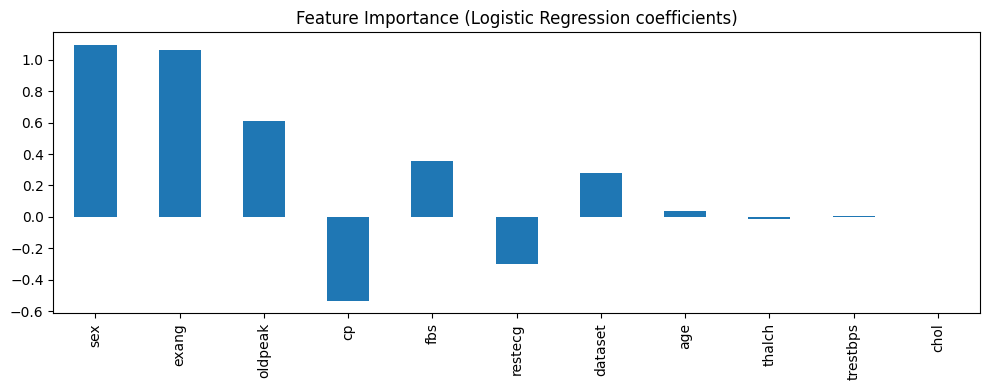

In [22]:
import matplotlib.pyplot as plt
import numpy as np

if best_name in ['Random Forest', 'Decision Tree']:
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    importances.plot(kind='bar', figsize=(10,4), title='Feature Importance')

elif best_name == 'Logistic Regression':
    importances = pd.Series(best_model.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
    importances.plot(kind='bar', figsize=(10,4), title='Feature Importance (Logistic Regression coefficients)')

elif best_name == 'KNN':
    from sklearn.inspection import permutation_importance
    result = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)
    importances = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)
    importances.plot(kind='bar', figsize=(10,4), title='Feature Importance (permutation)')

plt.tight_layout()
plt.savefig('../models/feature_importance.png')
plt.show()

In [23]:
joblib.dump(best_model, '../models/heart_model.pkl')
joblib.dump(list(X.columns), '../models/feature_columns.pkl')

['../models/feature_columns.pkl']